## Testing the Gadget for the $^{6}\text{Be}$ in the Quasiparticle Picture

### Imports

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity

### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{6}\text{Be}$ involves only one active quasiparticle proton, we don't need any two-body interaction

In [ ]:
data_onebody=np.load('data/matrix_elements_h_eff_2body/one_body_nn_p.npz')
keys=data_onebody['keys']
values=data_onebody['values']
n_qubits=6

g_onebody={}
diagonal_elements=np.zeros(n_qubits)
g_matrix=np.zeros((n_qubits,n_qubits))
for a,key in enumerate(keys):
    i,j=key
    g_onebody[(i,j)]=values[a]
    if i!=j:
        g_matrix[i,j]=values[a]
    if i==j:
        diagonal_elements[i]=values[a]    
        
        
# get the computational basis of the space
basis=computational_basis(n_qubits)


#### Write the NSM Quasiparticle Hamiltonian

In [193]:
hamiltonian_xy=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_xy+=SpinOperator([('x',i,'x',j)],coupling=[0.5*g_matrix[i,j]],size=n_qubits,verbose=1).qutip_op
        hamiltonian_xy+=SpinOperator([('y',i,'y',j)],coupling=[0.5*g_matrix[i,j]],size=n_qubits,verbose=1).qutip_op
hamiltonian_z=0.
for i in range(n_qubits):
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[diagonal_elements[i]],size=n_qubits,verbose=1).qutip_op
nsm_quasiparticle_hamiltonian=hamiltonian_z+hamiltonian_xy

In [194]:

eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [197]:
print(eigenvalues_nsm)
idx = np.argmin(np.abs(eigenvalues_nsm - (-11.93)))
print(eigenstates_nsm[idx].full())
print(basis)



[-36.63991036 -34.00512294 -31.42573525 -30.4631081  -28.9785
 -26.947004   -26.79936525 -26.28165061 -25.92305449 -25.03234572
 -24.16582559 -23.76893695 -23.45883039 -22.13995123 -22.03742993
 -21.87074281 -21.64775981 -21.33483307 -19.49819586 -19.19256792
 -18.90013522 -18.76440049 -18.35512028 -18.33681361 -17.72141267
 -16.80403762 -16.46424204 -15.99131682 -15.70928176 -15.62838253
 -14.64757723 -14.14659434 -13.95026196 -13.79840765 -13.3196634
 -13.25546103 -12.98549851 -12.23252152 -11.93178825 -11.52066825
 -11.4478368  -11.18341796 -10.04121252  -9.69152948  -9.068464
  -8.9655495   -8.34368578  -8.0583      -7.33926256  -7.03618801
  -6.16845416  -5.41818778  -4.72175158  -4.38543038  -3.85257428
  -3.59775693  -3.09672355  -1.97381051  -1.22817854  -0.20222782
   0.           3.07695081   4.2394495    7.26659732]
[[ 0.00000000e+00+0.j]
 [ 1.56619248e-01+0.j]
 [-1.56619248e-01+0.j]
 [ 5.55111512e-17+0.j]
 [-4.18149264e-01+0.j]
 [ 0.00000000e+00+0.j]
 [-3.41039969e-18+0.j]


Now, we get the spectrum of this Hamiltonian

### Puzzle of the Effective interaction

Following our notes on the gadget, we need to verify if we can reproduce the interaction by using the transverse field per site $d_i$. Since the relevant term in the effective Hamiltonian comes out as $H_{\text{int,eff}}=-\frac{1}{\gamma}\sum_{A \neq B} d_A d_B (X_A X_B +Y_A Y_B)$. We need to figure out if we can solve the condition $g_{AB}=-d_A d_B$. To do so, we treat it as an optimization problem. 

Optimal drive parameters: [-0.90513022  1.02535362 -0.96153052 -0.79417758 -1.10508836  1.13502171]
Optimized effective interaction matrix:
 [[ 0.00000000e+00  2.38278548e-01 -4.64010327e-01  1.81947764e-01
   9.31196815e-01  4.25607481e-01]
 [ 2.38278548e-01  0.00000000e+00  1.26008803e-01 -8.64690290e-02
  -5.12897746e-04  2.35762769e-01]
 [-4.64010327e-01  1.26008803e-01  0.00000000e+00  1.37155908e-01
  -3.27870146e-01 -7.07116593e-01]
 [ 1.81947764e-01 -8.64690290e-02  1.37155908e-01  0.00000000e+00
  -1.59923015e-01  1.83695413e-01]
 [ 9.31196815e-01 -5.12897746e-04 -3.27870146e-01 -1.59923015e-01
   0.00000000e+00  3.53399276e-01]
 [ 4.25607481e-01  2.35762769e-01 -7.07116593e-01  1.83695413e-01
   3.53399276e-01  0.00000000e+00]]


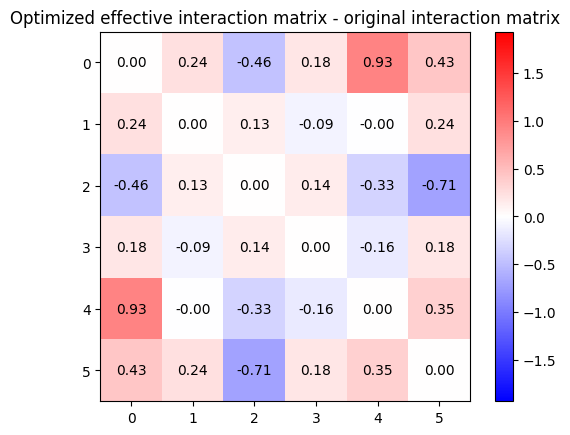

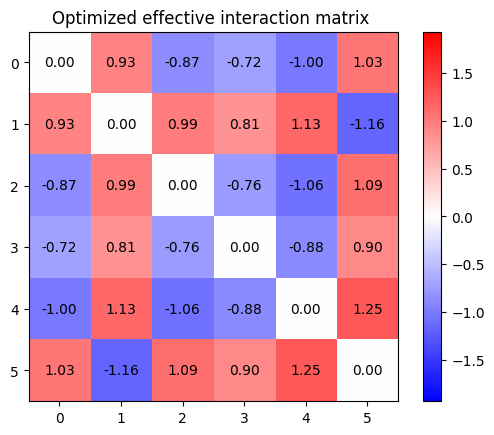

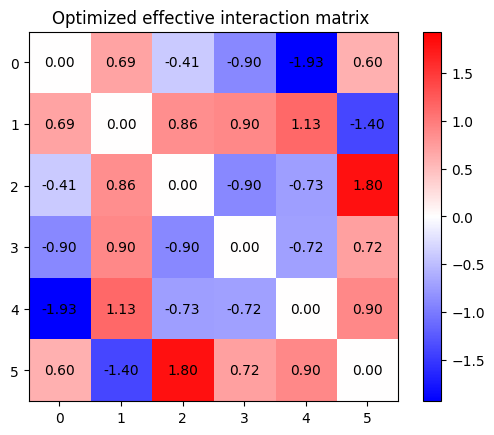

In [209]:
OptimalFieldBe6=EffectiveInteractionOptimizer(nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print("Optimized effective interaction matrix:\n", OptimalFieldBe6.reconstructed(d_opt)-g_matrix)
plt.imshow(OptimalFieldBe6.reconstructed(d_opt)-g_matrix, cmap='bwr', vmin=-np.max(np.abs(g_matrix)), vmax=np.max(np.abs(g_matrix)))
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(j, i, f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}", ha='center', va='center', color='black')
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

plt.imshow(OptimalFieldBe6.reconstructed(d_opt), cmap='bwr', vmin=-np.max(np.abs(g_matrix)), vmax=np.max(np.abs(g_matrix)))
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(j, i, f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]:.2f}", ha='center', va='center', color='black')
plt.colorbar()
plt.title("Optimized effective interaction matrix ")
plt.show()

plt.imshow(g_matrix, cmap='bwr', vmin=-np.max(np.abs(g_matrix)), vmax=np.max(np.abs(g_matrix)))
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(j, i, f"{g_matrix[i,j]:.2f}", ha='center', va='center', color='black')
plt.colorbar()
plt.title("Optimized effective interaction matrix ")
plt.show()

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### Define the hamiltonian $H_z$ out of the couplings and constrains

In [200]:
# get the total particle constrain 
gamma=100
ntot=1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field=(diagonal_elements+0.5*(d_opt**2).sum())/(gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz=0.
for i in range(n_qubits):
    for j in range(i+1,n_qubits):
        hamiltonian_zz+=SpinOperator([('qz',i,'qz',j)],coupling=[2*gamma],size=n_qubits,verbose=1).qutip_op

# then the linear terms
hamiltonian_z=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z+=SpinOperator([('qz',i)],coupling=[effective_longitudinal_field[i]+gamma*(1-2*ntot)],size=n_qubits,verbose=1).qutip_op

#finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space=qt.tensor([qt.qeye(2)] * n_qubits)

longitudinal_hamiltonian=hamiltonian_zz+hamiltonian_z+gamma*(ntot**2)*identity_qubit_space


In [201]:
print(longitudinal_hamiltonian.diag())
print(basis)

[ 1.00000000e+02  6.19278215e-02  6.19278215e-02  1.00123856e+02
 -5.13941785e-02  1.00010534e+02  1.00010534e+02  4.00072461e+02
 -6.17731785e-02  1.00000155e+02  1.00000155e+02  4.00062082e+02
  9.98868326e+01  3.99948760e+02  3.99948760e+02  9.00010688e+02
 -5.89381785e-02  1.00002990e+02  1.00002990e+02  4.00064917e+02
  9.98896676e+01  3.99951595e+02  3.99951595e+02  9.00013523e+02
  9.98792886e+01  3.99941216e+02  3.99941216e+02  9.00003144e+02
  3.99827894e+02  8.99889822e+02  8.99889822e+02  1.59995175e+03
 -6.34741785e-02  9.99984536e+01  9.99984536e+01  4.00060381e+02
  9.98851316e+01  3.99947059e+02  3.99947059e+02  9.00008987e+02
  9.98747526e+01  3.99936680e+02  3.99936680e+02  8.99998608e+02
  3.99823358e+02  8.99885286e+02  8.99885286e+02  1.59994721e+03
  9.98775876e+01  3.99939515e+02  3.99939515e+02  9.00001443e+02
  3.99826193e+02  8.99888121e+02  8.99888121e+02  1.59995005e+03
  3.99815814e+02  8.99877742e+02  8.99877742e+02  1.59993967e+03
  8.99764420e+02  1.59982

#### Plot a representation of the diagonal part of the Ising Hamiltonian

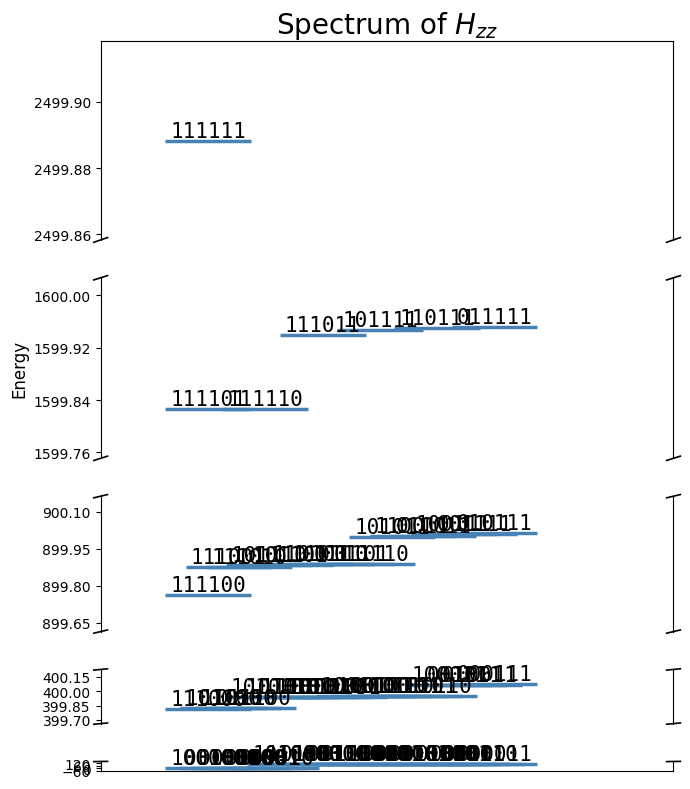

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#### this should go to the utils
def plot_spectrum(energies, basis, gap_threshold=0.3, figsize=(7, 8)):
    """
    Plot energy spectrum with broken axis to show both small splittings
    and large gaps between subspaces.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    gap_threshold : float
        Fraction of max gap used to detect subspace boundaries.
    figsize : tuple
    """
    labels = [''.join(map(str, row)) for row in basis]
    order = np.argsort(energies)
    sorted_energies = energies[order]
    sorted_labels = [labels[i] for i in order]

    # --- detect subspaces from large gaps ---
    gaps = np.diff(sorted_energies)
    max_gap = gaps.max()
    boundaries = np.where(gaps > gap_threshold * max_gap)[0]
    splits = np.split(np.arange(len(sorted_energies)), boundaries + 1)

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(n_panels, 1, figsize=figsize,
                             gridspec_kw={'height_ratios': heights},
                             squeeze=False)
    axes = axes.flatten()
    splits = splits[::-1]

    

    for ax, group in zip(axes, splits):

        es = sorted_energies[group]
        ls = [sorted_labels[i] for i in group]
        n = len(es)

        # stagger x positions to avoid label overlap
        x_positions = np.linspace(0.15, 0.55, max(n, 1))

        for x, e, label in zip(x_positions, es, ls):
            ax.hlines(e, x - 0.06, x + 0.06, linewidth=2.5, color='steelblue')
            ax.text(x, e, label, va='bottom', ha='center',
                    fontsize=15, fontfamily='monospace')

        span = es.max() - es.min()
        margin = max(span * 0.6, 0.03)
        ax.set_ylim(es.min() - margin, es.max() + margin)
        ax.set_xlim(0, 0.8)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines['top'].set_visible(False)

    # break marks between panels
    d = 0.012
    for ax_bot, ax_top in zip(axes[1:], axes[:-1]):
        for ax, y in [(ax_bot, 1), (ax_top, 0)]:
            kw = dict(color='k', clip_on=False, linewidth=1.2,
                      transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    axes[1].set_ylabel('Energy', fontsize=12)
    axes[0].set_title(r'Spectrum of $H_{zz}$', fontsize=20)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    axes[0].yaxis.set_major_formatter(formatter)
    axes[1].yaxis.set_major_formatter(formatter)
    axes[2].yaxis.set_major_formatter(formatter)
    plt.tight_layout()
    plt.show()




plot_spectrum(longitudinal_hamiltonian.diag(), basis)

### Part of the second step is to introduce the transverse field term

In [203]:
# the transverse field
transverse_hamiltonian=0.
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian+=SpinOperator([('x',i)],coupling=[d_opt[i]/np.sqrt(2)],size=n_qubits,verbose=1).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [204]:
total_hamiltonian=longitudinal_hamiltonian+transverse_hamiltonian
eigenvalues, eigenstates = total_hamiltonian.eigenstates()

print(basis)

[[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 0 0 0 1 1]
 [0 0 0 1 0 0]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]
 [0 0 0 1 1 1]
 [0 0 1 0 0 0]
 [0 0 1 0 0 1]
 [0 0 1 0 1 0]
 [0 0 1 0 1 1]
 [0 0 1 1 0 0]
 [0 0 1 1 0 1]
 [0 0 1 1 1 0]
 [0 0 1 1 1 1]
 [0 1 0 0 0 0]
 [0 1 0 0 0 1]
 [0 1 0 0 1 0]
 [0 1 0 0 1 1]
 [0 1 0 1 0 0]
 [0 1 0 1 0 1]
 [0 1 0 1 1 0]
 [0 1 0 1 1 1]
 [0 1 1 0 0 0]
 [0 1 1 0 0 1]
 [0 1 1 0 1 0]
 [0 1 1 0 1 1]
 [0 1 1 1 0 0]
 [0 1 1 1 0 1]
 [0 1 1 1 1 0]
 [0 1 1 1 1 1]
 [1 0 0 0 0 0]
 [1 0 0 0 0 1]
 [1 0 0 0 1 0]
 [1 0 0 0 1 1]
 [1 0 0 1 0 0]
 [1 0 0 1 0 1]
 [1 0 0 1 1 0]
 [1 0 0 1 1 1]
 [1 0 1 0 0 0]
 [1 0 1 0 0 1]
 [1 0 1 0 1 0]
 [1 0 1 0 1 1]
 [1 0 1 1 0 0]
 [1 0 1 1 0 1]
 [1 0 1 1 1 0]
 [1 0 1 1 1 1]
 [1 1 0 0 0 0]
 [1 1 0 0 0 1]
 [1 1 0 0 1 0]
 [1 1 0 0 1 1]
 [1 1 0 1 0 0]
 [1 1 0 1 0 1]
 [1 1 0 1 1 0]
 [1 1 0 1 1 1]
 [1 1 1 0 0 0]
 [1 1 1 0 0 1]
 [1 1 1 0 1 0]
 [1 1 1 0 1 1]
 [1 1 1 1 0 0]
 [1 1 1 1 0 1]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


In [205]:
print(total_hamiltonian[:,[1,2,4]][[1,2,4],:]*gamma)

print(nsm_quasiparticle_hamiltonian[:,[1,2,4]][[1,2,4],:])

hamiltonian_ab=total_hamiltonian[:,[1,2,4]][[0,3,5,6],:]

print(total_hamiltonian[:,[1,2,4]][[1,2,4],:]*gamma-hamiltonian_ab.T @ hamiltonian_ab)

[[ 6.19278215+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  6.19278215+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j -5.13941785+0.j]]
[[ 3.2251    +0.j  0.9009    +0.j  0.71771338+0.j]
 [ 0.9009    +0.j  3.2251    +0.j -0.71771338+0.j]
 [ 0.71771338+0.j -0.71771338+0.j -8.1071    +0.j]]
[[ 4.62267585+0.j  1.25429928+0.j  0.9014088 +0.j]
 [ 1.25429928+0.j  4.62267585+0.j -0.8776364 +0.j]
 [ 0.9014088 +0.j -0.8776364 +0.j -6.70952415+0.j]]


In [207]:
print(eigenvalues[:3]*gamma)

print(eigenstates[0].full())
print(basis)

print(fidelity(eigenstates[0], eigenstates_nsm[idx]))

[-12.08847159  -8.38389462  -8.00120392]
[[-1.50159013e-02-0.j]
 [-1.45164165e-01+0.j]
 [ 1.41907815e-01+0.j]
 [ 2.26830353e-03+0.j]
 [ 3.65757902e-01+0.j]
 [ 3.74642019e-03+0.j]
 [-3.65083331e-03+0.j]
 [-1.78202749e-05+0.j]
 [ 5.28024722e-01+0.j]
 [ 5.21925566e-03+0.j]
 [-5.08550553e-03+0.j]
 [-2.42447515e-05+0.j]
 [-5.45238039e-03+0.j]
 [-2.46315275e-05+0.j]
 [ 2.39928719e-05+0.j]
 [ 7.13619069e-08+0.j]
 [-5.09075179e-01+0.j]
 [-5.13263301e-03+0.j]
 [ 5.00142501e-03+0.j]
 [ 2.41626086e-05+0.j]
 [ 5.51086940e-03+0.j]
 [ 2.50497066e-05+0.j]
 [-2.44007470e-05+0.j]
 [-7.29305769e-08+0.j]
 [ 7.29048752e-03+0.j]
 [ 3.28080120e-05+0.j]
 [-3.19569081e-05+0.j]
 [-9.47552849e-08+0.j]
 [-2.94895939e-05+0.j]
 [-8.55346791e-08+0.j]
 [ 8.33053619e-08+0.j]
 [ 1.80138651e-10+0.j]
 [ 5.35149909e-01+0.j]
 [ 5.21863913e-03+0.j]
 [-5.08467738e-03+0.j]
 [-2.40159378e-05+0.j]
 [-5.34661920e-03+0.j]
 [-2.40451324e-05+0.j]
 [ 2.34213009e-05+0.j]
 [ 6.94110631e-08+0.j]
 [-7.01920901e-03+0.j]
 [-3.13012550e-0